In [2]:
import pandas as pd
import glob
import os

# 1. Path to your folder containing .xlsx files
path = 'NSW_WA_2022_fuelprice/NSW/*.xlsx'
all_files = glob.glob(path)

# 2. Combine into one DataFrame (assuming they share the same structure)
# We use a list comprehension to read each file
df_list = []
for filename in all_files:
    df = pd.read_excel(filename) # 'openpyxl' is used by default
    df_list.append(df)

combined_df = pd.concat(df_list, ignore_index=True)


In [3]:
# 3. Remove columns
df = combined_df.copy()  # Keep original combined_df intact for debugging
df.columns = df.iloc[1].tolist()
if 'Price'in df.columns:
    cols = df.columns.tolist()
    cut_index = cols.index('Price') + 1
    df = df.loc[:, cols[:cut_index]]
else:
    print("Warning: 'Price' not found in df columns.")

df = df.iloc[2:].reset_index(drop=True)
print('Columns after header reset and trimming:', df.columns.tolist())


Columns after header reset and trimming: ['ServiceStationName', 'Address', 'Suburb', 'Postcode', 'Brand', 'FuelCode', 'PriceUpdatedDate', 'Price']


In [4]:
# Group by PriceUpdatedDate and copy the first row's station metadata to every row in that date group
metadata_cols = ['ServiceStationName', 'Address', 'Suburb', 'Postcode', 'Brand']

first_metadata = df.groupby('PriceUpdatedDate')[metadata_cols].transform('first')
df.loc[:, metadata_cols] = first_metadata

# Create a subsample containing only FuelCode == 'U91'
df_u91 = df[df['FuelCode'] == 'U91'].copy()


C:\Users\王润彬\AppData\Local\Temp\ipykernel_15444\2815558235.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  march_apr['PriceUpdatedDate'] = pd.to_datetime(march_apr['PriceUpdatedDate'], errors='coerce')
C:\Users\王润彬\AppData\Local\Temp\ipykernel_15444\2815558235.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  brand_plot_df['PriceUpdatedDate'] = pd.to_datetime(brand_plot_df['PriceUpdatedDate'], errors='coerce')


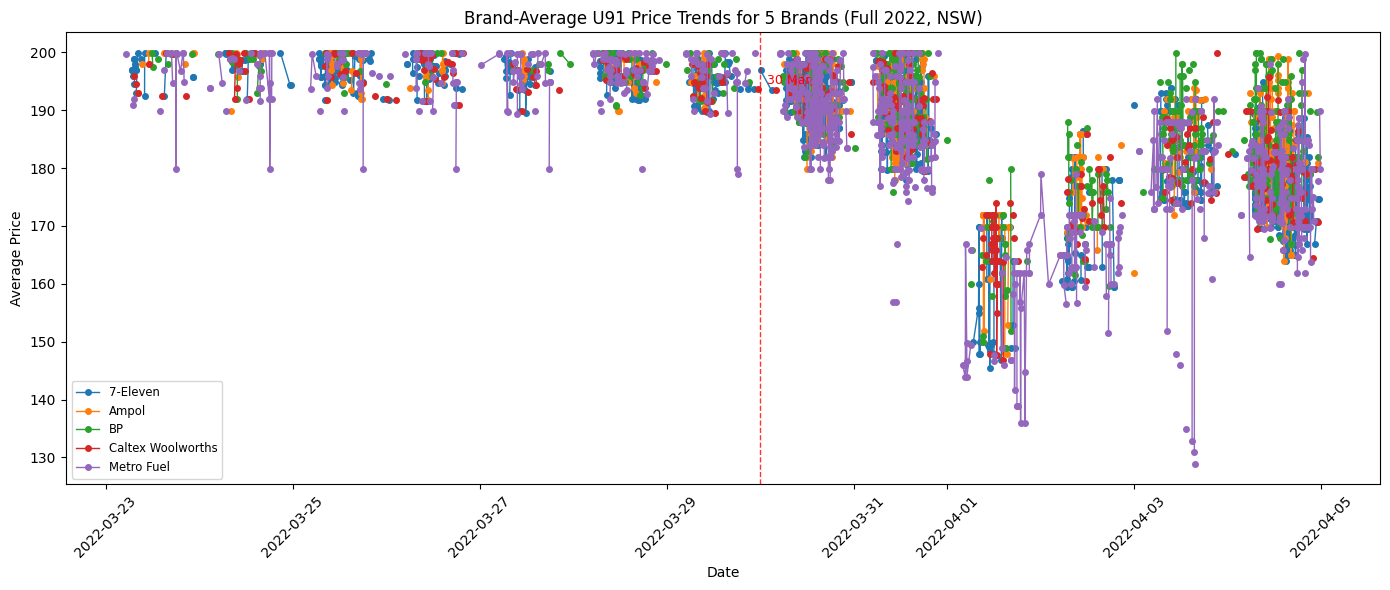

C:\Users\王润彬\AppData\Local\Temp\ipykernel_15444\2815558235.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best', fontsize='small')


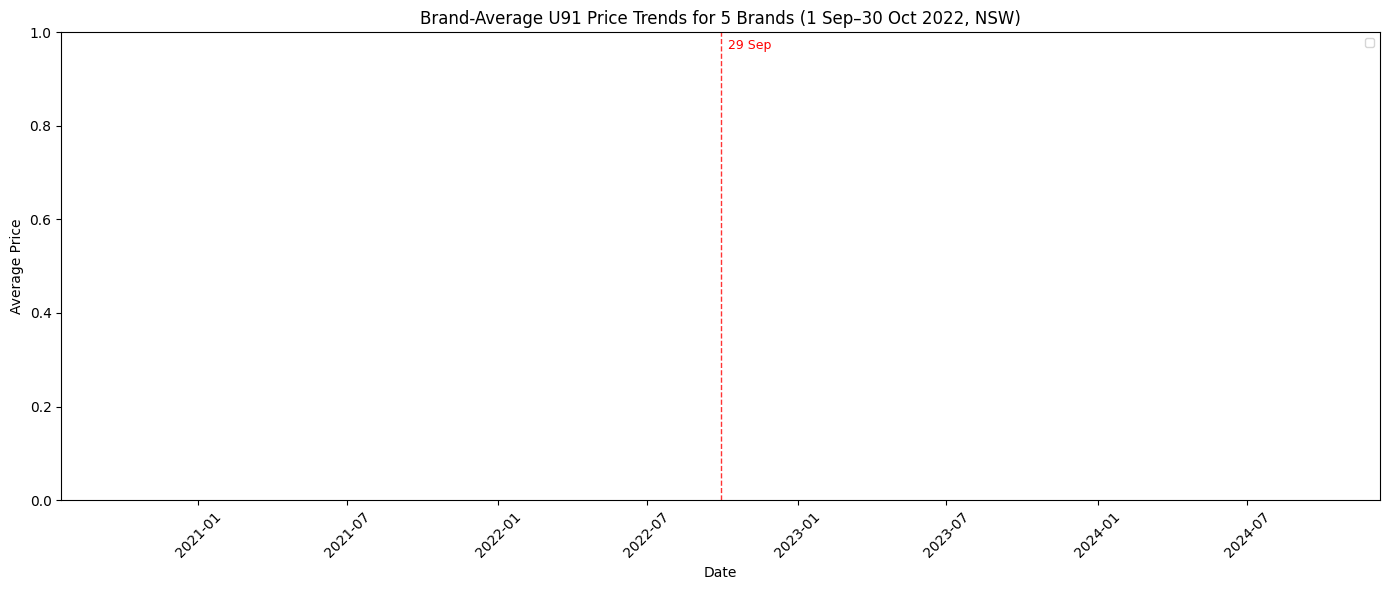

In [ ]:
# Focus on 23 March to 7 April, using weekly averages
march_apr = df_u91.copy()
march_apr['PriceUpdatedDate'] = pd.to_datetime(march_apr['PriceUpdatedDate'], errors='coerce')
march_apr = march_apr[(march_apr['PriceUpdatedDate'] >= '2022-01-01') & (march_apr['PriceUpdatedDate'] <= '2022-06-30')].copy()

# Brand-average price trends for NSW U91
brand_plot_df = df_u91.copy()
brand_plot_df = brand_plot_df.dropna(subset=['Brand', 'Price', 'PriceUpdatedDate'])
brand_plot_df['PriceUpdatedDate'] = pd.to_datetime(brand_plot_df['PriceUpdatedDate'], errors='coerce')
brand_plot_df = brand_plot_df[(brand_plot_df['PriceUpdatedDate'] >= '2022-03-23') & (brand_plot_df['PriceUpdatedDate'] <= '2022-04-07')].copy()

brand_counts = brand_plot_df['Brand'].value_counts().head(5).index.tolist()
brand_trends = (
    brand_plot_df[brand_plot_df['Brand'].isin(brand_counts)]
    .groupby(['PriceUpdatedDate', 'Brand'])['Price']
    .mean()
    .unstack('Brand')
    .sort_index()
)

plt.figure(figsize=(14, 6))
for brand in brand_trends.columns:
    plt.plot(brand_trends.index, brand_trends[brand], marker='o', linewidth=1, markersize=4, label=brand)

plt.axvline(pd.Timestamp('2022-03-30'), color='red', linestyle='--', linewidth=1, alpha=0.8)
plt.annotate('30 Mar', xy=(pd.Timestamp('2022-03-30'), plt.gca().get_ylim()[1] * 0.95),
             xytext=(5, 5), textcoords='offset points', color='red', fontsize=9)

plt.title('Brand-Average U91 Price Trends for 5 Brands (Full 2022, NSW)')
plt.xlabel('Date')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.legend(loc='best', fontsize='small')
plt.tight_layout()
plt.show()

# Brand-average price trends for NSW U91 from 1 Sep to 30 Oct
brand_plot_sep = brand_plot_df[(brand_plot_df['PriceUpdatedDate'] >= '2022-09-23') & (brand_plot_df['PriceUpdatedDate'] <= '2022-10-07')].copy()
sep_brand_counts = brand_plot_sep['Brand'].value_counts().head(5).index.tolist()
sep_brand_trends = (
    brand_plot_sep[brand_plot_sep['Brand'].isin(sep_brand_counts)]
    .groupby(['PriceUpdatedDate', 'Brand'])['Price']
    .mean()
    .unstack('Brand')
    .sort_index()
)

plt.figure(figsize=(14, 6))
for brand in sep_brand_trends.columns:
    plt.plot(sep_brand_trends.index, sep_brand_trends[brand], marker='o', linewidth=1, markersize=4, label=brand)

plt.axvline(pd.Timestamp('2022-09-29'), color='red', linestyle='--', linewidth=1, alpha=0.8)
plt.annotate('29 Sep', xy=(pd.Timestamp('2022-09-29'), plt.gca().get_ylim()[1] * 0.95),
             xytext=(5, 5), textcoords='offset points', color='red', fontsize=9)

plt.title('Brand-Average U91 Price Trends for 5 Brands (1 Sep–30 Oct 2022, NSW)')
plt.xlabel('Date')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.legend(loc='best', fontsize='small')
plt.tight_layout()
plt.show()